# Testing 21cmFast

## Initial testing

### Importing modules

In [1]:
import py21cmfast as p21c
from tempfile import mkdtemp
from pathlib import Path
from matplotlib import pyplot as plt

print(f' Using 21cmFAST version {p21c.__version__}')

 Using 21cmFAST version 4.2


### Defining Simulation inputs

The list of template configurations we want to load as defaults include:
- The configuration from Park et al. 2019 (`Park19`)
- A box with preset size and resolution

In [ ]:
# Define inputs - a small one for testing and a large one for the science
scin_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"], random_seed=20250303, HII_DIM=600, LOWRES_CELL_SIZE_MPC=2, N_THREADS=8
)

test_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"], random_seed=20250303, HII_DIM=300, LOWRES_CELL_SIZE_MPC=2, N_THREADS=8
)

test_toml_file = "test-park19.toml"
scin_toml_file = "scin-park19.toml"

p21c.write_template(test_inputs, test_toml_file)
p21c.write_template(scin_inputs, scin_toml_file)

## Running the test lightcone file

In [3]:
cache = p21c.OutputCache(mkdtemp())

lcn = p21c.RectilinearLightconer.between_redshifts(
    min_redshift=5.5,
    max_redshift=12.0,
    quantities=("brightness_temp", "density"),
    resolution=test_inputs.simulation_options.cell_size
)

In [4]:
lightcone = p21c.run_lightcone(
    lightconer=lcn,
    inputs=test_inputs,
    cache=cache,
    progressbar=True
)

Output()

Output()

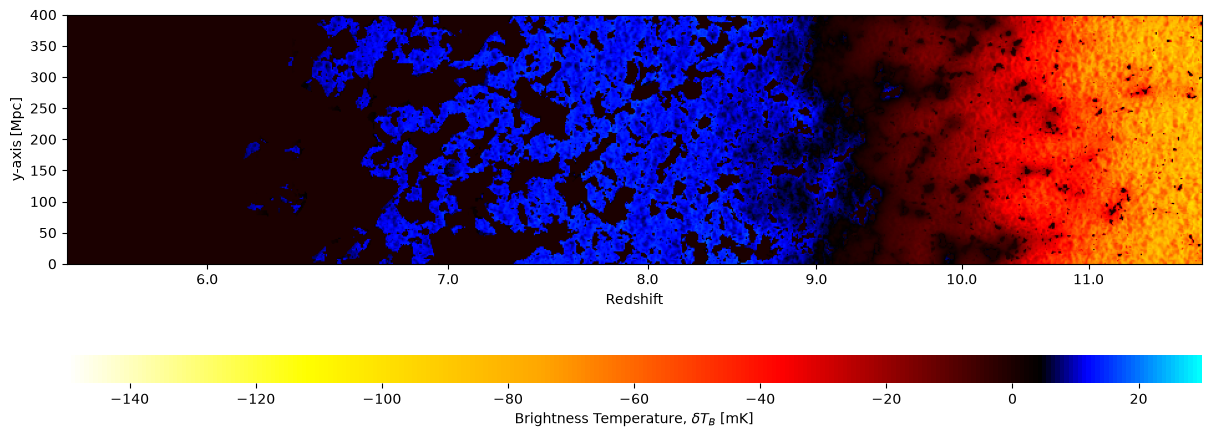

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
p21c.plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);

In [6]:
print(lightcone.lightcones)

{'brightness_temp': array([[[  0.      ,   0.      ,   0.      , ..., -69.27853 ,
         -72.66494 , -68.35472 ],
        [  0.      ,   0.      ,   0.      , ..., -69.95312 ,
         -71.72086 , -67.25024 ],
        [  0.      ,   0.      ,   0.      , ..., -64.2196  ,
         -62.325176, -62.079666],
        ...,
        [  0.      ,   0.      ,   0.      , ..., -57.76766 ,
         -69.18472 , -63.555885],
        [  0.      ,   0.      ,   0.      , ..., -57.85452 ,
         -66.46014 , -65.43921 ],
        [  0.      ,   0.      ,   0.      , ..., -65.91131 ,
         -68.39071 , -68.99155 ]],

       [[  0.      ,   0.      ,   0.      , ..., -56.00405 ,
         -65.91885 , -65.354774],
        [  0.      ,   0.      ,   0.      , ..., -66.36442 ,
         -69.13375 , -63.569305],
        [  0.      ,   0.      ,   0.      , ..., -67.445015,
         -61.62006 , -64.83696 ],
        ...,
        [  0.      ,   0.      ,   0.      , ..., -55.380505,
         -62.098404, -68.7